In [43]:
pip install sns_heatmap

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sns_heatmap (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for sns_heatmap


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# 1. Data Discovery

Load Dataset

In [45]:
df_events = pd.read_json('stream_events.jsonl', lines=True)
df_events.head()

,event_id,event_time,user_id,dept,role,device_type,source_ip,asset_id,asset_type,data_classification,action,status,bytes_out,records_accessed,latency_ms,risk_score,label
0,EVT0000001,2026-05-27 12:59:43,U0137,Operations,admin,server,10.10.3.166,cust_db,database,restricted,upload,success,18209,193,95,0,normal
1,EVT0000002,2026-05-27 12:59:53,U0067,Data Science,intern,server,10.10.13.73,public_web,web,public,read,success,36452,280,127,1,normal
2,EVT0000003,2026-05-27 13:00:03,U0121,Sales,admin,laptop,10.10.8.168,cust_db,database,restricted,query,success,196646,508,143,25,normal
3,EVT0000004,2026-05-27 13:00:13,U0064,Sales,manager,mobile,10.10.16.173,data_lake,storage,restricted,download,success,53304,223,104,4,normal
4,EVT0000005,2026-05-27 13:00:23,U0095,Operations,analyst,vpn_gateway,10.10.6.248,crm,saas,confidential,query,success,157538,11252,109,4,normal


In [46]:
df_users = pd.read_csv('users.csv')
df_users.head()

,user_id,employee_id,dept,role,clearance,location,status
0,U0001,E00001,Data Science,analyst,public,Surabaya,active
1,U0002,E00002,HR,manager,public,Surabaya,active
2,U0003,E00003,Legal,analyst,restricted,Jakarta,active
3,U0004,E00004,HR,manager,public,Surabaya,active
4,U0005,E00005,Data Science,admin,restricted,Jakarta,active


In [47]:
df_assets = pd.read_csv('assets.csv')
df_assets.head()

,asset_id,asset_type,data_classification
0,cust_db,database,restricted
1,payroll,database,confidential
2,crm,saas,confidential
3,data_lake,storage,restricted
4,git_repo,code,internal


schema, jumlah baris, missing value, duplicate event_id

In [48]:
print("df_events columns:\n", ", ".join(df_events.columns))
print("\ndf_users columns:\n", ", ".join(df_users.columns))
print("\ndf_assets columns:\n", ", ".join(df_assets.columns))

df_events columns:
 event_id, event_time, user_id, dept, role, device_type, source_ip, asset_id, asset_type, data_classification, action, status, bytes_out, records_accessed, latency_ms, risk_score, label

df_users columns:
 user_id, employee_id, dept, role, clearance, location, status

df_assets columns:
 asset_id, asset_type, data_classification


In [49]:
print("df_events rows:", len(df_events))
print("df_users rows:", len(df_users))
print("df_assets rows:", len(df_assets))

df_events rows: 100000
df_users rows: 150
df_assets rows: 8


In [50]:
print("missing value")

print("\n[df_events]:")
print(df_events.isnull().sum()[df_events.isnull().sum() > 0] if df_events.isnull().sum().sum() > 0 else "Tidak ada missing value")

print("\n[df_users]:")
print(df_users.isnull().sum()[df_users.isnull().sum() > 0] if df_users.isnull().sum().sum() > 0 else "Tidak ada missing value")

print("\n[df_assets]:")
print(df_assets.isnull().sum()[df_assets.isnull().sum() > 0] if df_assets.isnull().sum().sum() > 0 else "Tidak ada missing value")

missing value

[df_events]:
Tidak ada missing value

[df_users]:
Tidak ada missing value

[df_assets]:
Tidak ada missing value


In [51]:
duplicate_count = df_events.duplicated(subset=['event_id']).sum()
print(f"Jumlah baris dengan event_id duplikat: {duplicate_count}")

Jumlah baris dengan event_id duplikat: 0


distribusi action, status, data_classification

=== DISTRIBUSI KOLOM: ACTION ===
                   Count  Percentage (%)
action                                  
read               25675           25.67
login              22678           22.68
query              18532           18.53
download           10306           10.31
logout              8293            8.29
upload              6182            6.18
schema_discovery    5255            5.26
delete              2049            2.05
permission_change   1030            1.03


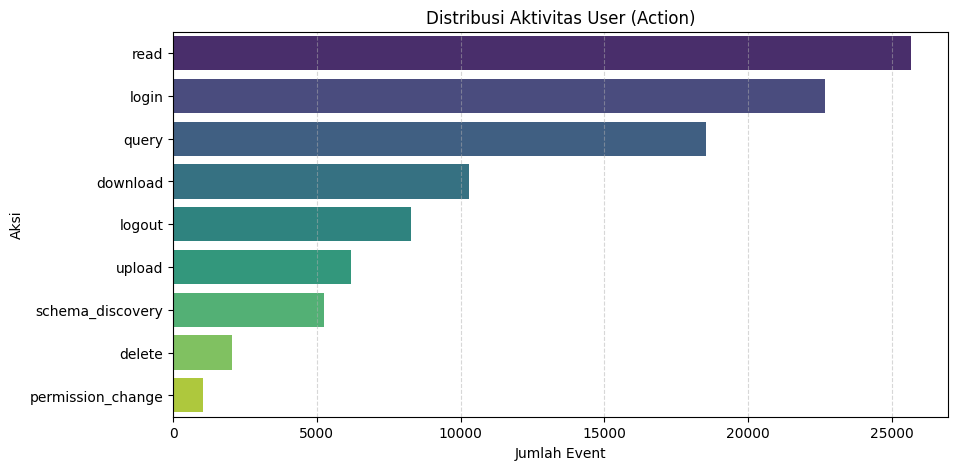

In [52]:
print("=== DISTRIBUSI KOLOM: ACTION ===")
# 1. Tampilkan Tabel Ringkas
df_action = df_events['action'].value_counts().to_frame(name='Count')
df_action['Percentage (%)'] = (df_events['action'].value_counts(normalize=True) * 100).round(2)
print(df_action)

# 2. Visualisasi Bar Plot Horizontal (Cocok untuk kategori yang banyak)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_events, y='action', order=df_events['action'].value_counts().index, palette='viridis')
plt.title('Distribusi Aktivitas User (Action)')
plt.xlabel('Jumlah Event')
plt.ylabel('Aksi')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

=== DISTRIBUSI KOLOM: STATUS ===
         Count  Percentage (%)
status                        
success  89946           89.95
failed   10054           10.05


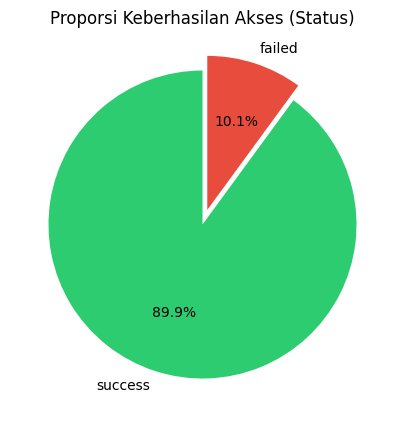

In [53]:
print("=== DISTRIBUSI KOLOM: STATUS ===")
# 1. Tampilkan Tabel Ringkas
df_status = df_events['status'].value_counts().to_frame(name='Count')
df_status['Percentage (%)'] = (df_events['status'].value_counts(normalize=True) * 100).round(2)
print(df_status)

# 2. Visualisasi Pie Chart (Cocok untuk kategori sedikit/biner)
plt.figure(figsize=(5, 5))
df_events['status'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.1))
plt.title('Proporsi Keberhasilan Akses (Status)')
plt.ylabel('') # Menghilangkan label y otomatis
plt.show()

=== DISTRIBUSI KOLOM: DATA CLASSIFICATION ===
                     Count  Percentage (%)
data_classification                       
internal             37631           37.63
restricted           25011           25.01
confidential         24986           24.99
public               12372           12.37


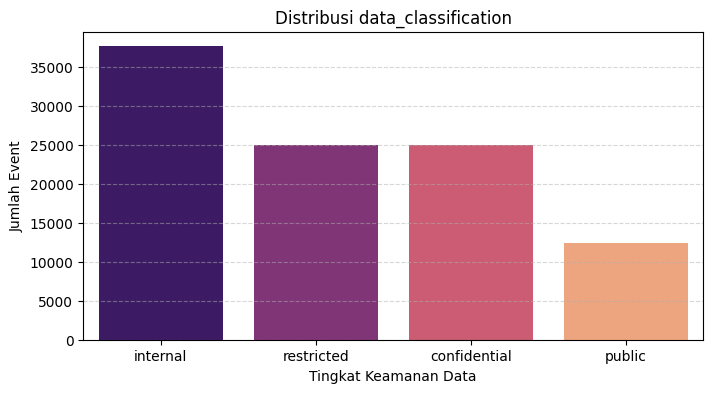

In [54]:
print("=== DISTRIBUSI KOLOM: DATA CLASSIFICATION ===")
# 1. Tampilkan Tabel Ringkas
df_class = df_events['data_classification'].value_counts().to_frame(name='Count')
df_class['Percentage (%)'] = (df_events['data_classification'].value_counts(normalize=True) * 100).round(2)
print(df_class)

# 2. Visualisasi Bar Plot Vertikal
plt.figure(figsize=(8, 4))
sns.countplot(data=df_events, x='data_classification', order=df_events['data_classification'].value_counts().index, palette='magma')
plt.title('Distribusi data_classification')
plt.xlabel('Tingkat Keamanan Data')
plt.ylabel('Jumlah Event')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

top 5 user dan access

In [55]:
top_users = df_events['user_id'].value_counts().head(5).to_frame(name='Jumlah Event')
top_users['Persentase (%)'] = (df_events['user_id'].value_counts(normalize=True).head(5) * 100).round(2)
print(top_users)

         Jumlah Event  Persentase (%)
user_id                              
U0136             734            0.73
U0002             721            0.72
U0037             718            0.72
U0104             717            0.72
U0135             716            0.72


In [56]:
top_assets = df_events['asset_id'].value_counts().head(5).to_frame(name='Jumlah Akses')
top_assets['Persentase (%)'] = (df_events['asset_id'].value_counts(normalize=True).head(5) * 100).round(2)
print(top_assets)

              Jumlah Akses  Persentase (%)
asset_id                                  
payroll              12633           12.63
git_repo             12632           12.63
bi_dashboard         12577           12.58
data_lake            12521           12.52
cust_db              12490           12.49


Data Dictionary ditulis di laporan

In [57]:
# Menampilkan tipe data dan jumlah baris non-null untuk memastikan kesesuaian skema
df_events[['event_id', 'event_time', 'user_id', 'source_ip', 'asset_id', 
           'data_classification', 'action', 'bytes_out', 'risk_score', 'label']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   event_id             100000 non-null  object        
 1   event_time           100000 non-null  datetime64[ns]
 2   user_id              100000 non-null  object        
 3   source_ip            100000 non-null  object        
 4   asset_id             100000 non-null  object        
 5   data_classification  100000 non-null  object        
 6   action               100000 non-null  object        
 7   bytes_out            100000 non-null  int64         
 8   risk_score           100000 non-null  int64         
 9   label                100000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 7.6+ MB


# Data Science

Feature Engineering

In [58]:
# Wajib diurutkan berdasarkan user_id dan waktu agar fitur 'rolling' tidak membaca masa depan
df_events = df_events.sort_values(by=['user_id', 'event_time'])

# Merge untuk mendapatkan konteks dari df_users
# ubah nama kolom 'status' dari df_users menjadi 'employee_status' agar tidak bentrok dengan kolom 'status' di df_events
df_users_subset = df_users[['user_id', 'clearance', 'status']].rename(columns={'status': 'employee_status'})
df_events = df_events.merge(df_users_subset, on='user_id', how='left')
df_events.head()

,event_id,event_time,user_id,dept,role,device_type,source_ip,asset_id,asset_type,data_classification,action,status,bytes_out,records_accessed,latency_ms,risk_score,label,clearance,employee_status
0,EVT0000156,2026-05-27 13:25:33,U0001,Data Science,analyst,laptop,10.10.3.140,data_lake,storage,restricted,query,failed,124108,259,127,32,normal,public,active
1,EVT0000238,2026-05-27 13:39:13,U0001,Data Science,analyst,mobile,10.10.12.100,cust_db,database,restricted,upload,failed,95295,199,120,25,normal,public,active
2,EVT0000325,2026-05-27 13:53:43,U0001,Data Science,analyst,server,10.10.17.145,payroll,database,confidential,download,success,149334,306,110,30,normal,public,active
3,EVT0000388,2026-05-27 14:04:13,U0001,Data Science,analyst,vpn_gateway,10.10.13.105,crm,saas,confidential,login,success,71807,8975,149,26,normal,public,active
4,EVT0000722,2026-05-27 14:59:53,U0001,Data Science,analyst,server,10.10.18.231,ticketing,saas,internal,login,success,110814,283,121,6,normal,public,active


In [ ]:
## Fitur Kontekstual (Rule-Based Context)

# A. Pelanggaran Akses (Clearance rendah vs Aset Tinggi)
df_events['is_clearance_violation'] = (
    df_events['clearance'].isin(['public', 'internal']) & 
    df_events['data_classification'].isin(['restricted', 'confidential'])
).astype(int)

# B. Akses oleh akun yang sudah non-aktif (Terminated / Resign)
df_events['is_terminated_access'] = (df_events['employee_status'] == 'terminated').astype(int)

# C. Aksi berisiko tinggi
df_events['is_high_risk_action'] = df_events['action'].isin(['delete', 'permission_change']).astype(int)
df_events[['event_time', 'is_clearance_violation', 'is_terminated_access', 'is_high_risk_action']].head()

,event_time,is_clearance_violation,is_terminated_access,is_high_risk_action
0,2026-05-27 13:25:33,1,0,0
1,2026-05-27 13:39:13,1,0,0
2,2026-05-27 13:53:43,1,0,0
3,2026-05-27 14:04:13,1,0,0
4,2026-05-27 14:59:53,0,0,0


In [ ]:
## Fitur Ekstraksi Waktu (Temporal Features)
# asumsikan jam kerja normal adalah 08:00 hingga 18:00
df_events['is_outside_working_hours'] = ((df_events['event_time'].dt.hour < 8) | (df_events['event_time'].dt.hour > 18)).astype(int)

# Deteksi akses di akhir pekan (Sabtu=5, Minggu=6)
df_events['is_weekend'] = (df_events['event_time'].dt.dayofweek >= 5).astype(int)

df_events[['event_time', 'is_outside_working_hours', 'is_weekend']].head()

,event_time,is_outside_working_hours,is_weekend
0,2026-05-27 13:25:33,0,0
1,2026-05-27 13:39:13,0,0
2,2026-05-27 13:53:43,0,0
3,2026-05-27 14:04:13,0,0
4,2026-05-27 14:59:53,0,0


In [ ]:
## Fitur Jendela Waktu (Rolling Window / Stateful)
# Pindahkan event_time ke index sementara agar fungsi .rolling() dari Pandas bisa menggunakan parameter waktu ('1h')
df_events = df_events.set_index('event_time')

# Kolom bantuan (flag) untuk menghitung gagal login
df_events['is_failed_login'] = ((df_events['action'] == 'login') & (df_events['status'] == 'failed')).astype(int)

# A. Akumulasi Bytes Out dalam 1 jam terakhir
df_events['rolling_bytes_1h'] = df_events.groupby('user_id')['bytes_out'].rolling('1h').sum().reset_index(level=0, drop=True)

# B. Jumlah gagal login dalam 1 jam terakhir
df_events['rolling_failed_logins_1h'] = df_events.groupby('user_id')['is_failed_login'].rolling('1h').sum().reset_index(level=0, drop=True)

# C. Jumlah aktivitas (Event Count) dalam 1 jam terakhir
df_events['event_count_1h'] = df_events.groupby('user_id')['action'].rolling('1h').count().reset_index(level=0, drop=True)

# Kembalikan index menjadi kolom biasa dan buang kolom bantuan
df_events = df_events.reset_index().drop(columns=['is_failed_login'])

df_events[['event_time', 'user_id', 'rolling_bytes_1h', 'rolling_failed_logins_1h', 'event_count_1h']].head()

,event_time,user_id,rolling_bytes_1h,rolling_failed_logins_1h,event_count_1h
0,2026-05-27 13:25:33,U0001,124108.0,0.0,1.0
1,2026-05-27 13:39:13,U0001,219403.0,0.0,2.0
2,2026-05-27 13:53:43,U0001,368737.0,0.0,3.0
3,2026-05-27 14:04:13,U0001,440544.0,0.0,4.0
4,2026-05-27 14:59:53,U0001,182621.0,0.0,2.0


In [ ]:
# Anomali = 1, Normal = 0
df_events['target'] = (df_events['label'] != 'normal').astype(int)

In [63]:
print(f"Dimensi Data Baru: {df_events.shape}")

Dimensi Data Baru: (100000, 28)


EDA

In [69]:
features = [
    'is_clearance_violation', 'is_terminated_access', 'is_high_risk_action',
    'is_outside_working_hours', 'is_weekend', 'rolling_bytes_1h',
    'rolling_failed_logins_1h', 'event_count_1h', 'target'
]

In [71]:
print(df_events[features].describe())

       is_clearance_violation  is_terminated_access  is_high_risk_action  \
count           100000.000000         100000.000000        100000.000000   
mean                 0.245820              0.066970             0.030790   
std                  0.430574              0.249971             0.172749   
min                  0.000000              0.000000             0.000000   
25%                  0.000000              0.000000             0.000000   
50%                  0.000000              0.000000             0.000000   
75%                  0.000000              0.000000             0.000000   
max                  1.000000              1.000000             1.000000   

       is_outside_working_hours     is_weekend  rolling_bytes_1h  \
count             100000.000000  100000.000000      1.000000e+05   
mean                   0.542780       0.345600      2.991412e+05   
std                    0.498169       0.475566      1.913082e+06   
min                    0.000000       0.000

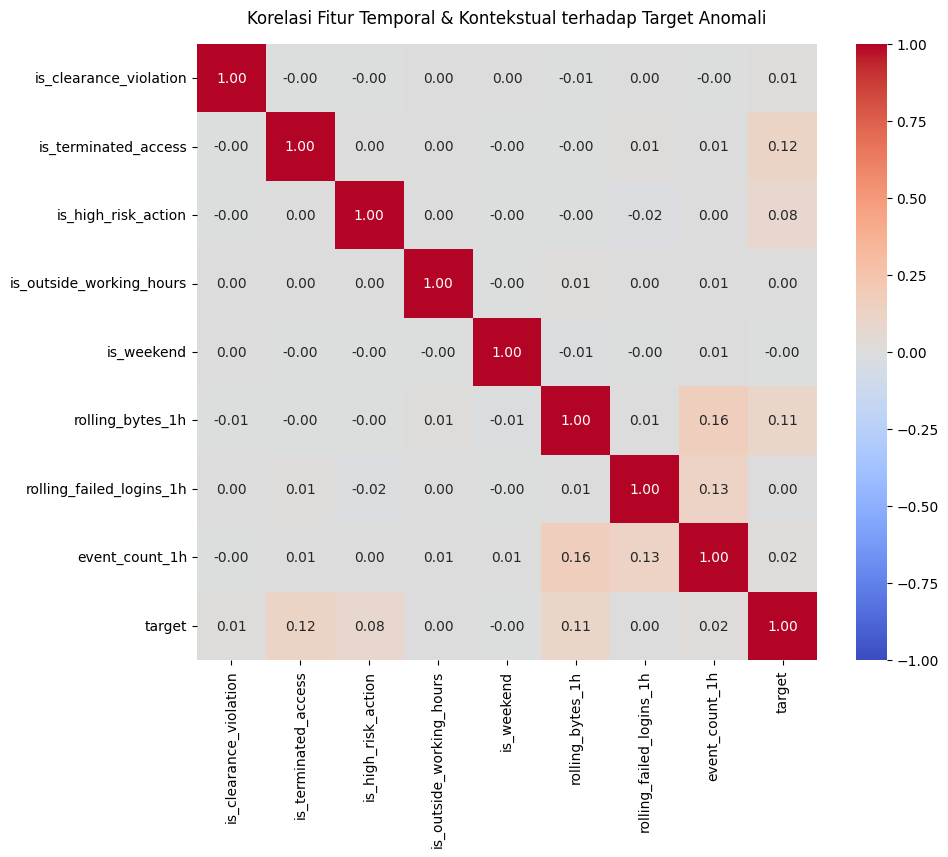

In [ ]:
plt.figure(figsize=(10, 8))
# Hitung korelasi pearson
corr_matrix = df_events[features].corr()

# Tampilkan Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Fitur Temporal & Kontekstual terhadap Target Anomali', pad=15, fontsize=12)
plt.show()

Nilai korelasi pearson yang rendah (di bawah 0.2) membuktikan bahwa pendeteksian serangan siber bukanlah masalah yang bisa dipecahkan dengan regresi linear sederhana. Anomali terbentuk dari kombinasi kondisi (misalnya: user terminated + akses di luar jam kerja), bukan dari kenaikan satu variabel secara proporsional.

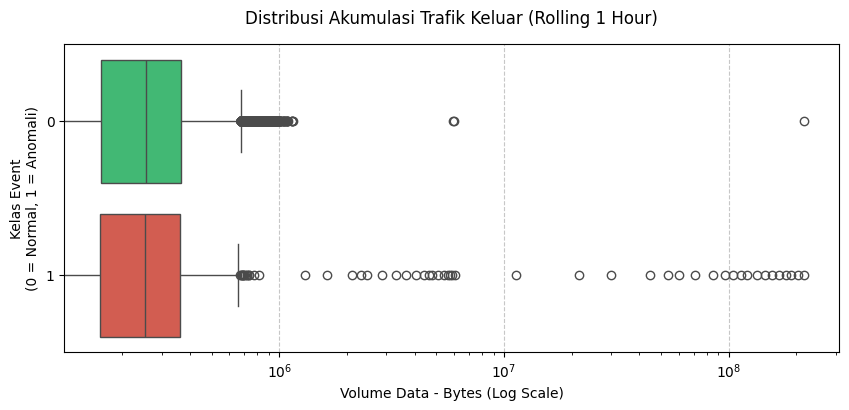

In [67]:
plt.figure(figsize=(10, 4))
# Menggunakan skala log untuk menyeimbangkan visualisasi
sns.boxplot(
    data=df_events, 
    x='rolling_bytes_1h', 
    y=df_events['target'].astype(str), 
    palette=['#2ecc71', '#e74c3c']
)

plt.xscale('log')
plt.title('Distribusi Akumulasi Trafik Keluar (Rolling 1 Hour)', pad=15)
plt.xlabel('Volume Data - Bytes (Log Scale)')
plt.ylabel('Kelas Event\n(0 = Normal, 1 = Anomali)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Sebaran Kelas Normal (0): Aktivitas pengguna normal sangat padat dan terpusat di bawah ambang batas sekitar 1 MB per jam.Ekor Panjang Kelas Anomali (1): Terdapat sebaran outlier yang sangat panjang dan masif pada kelas anomali. Titik-titik ini memanjang dari 1 MB hingga mencapai lebih dari 200 MB dalam rentang waktu 1 jam.

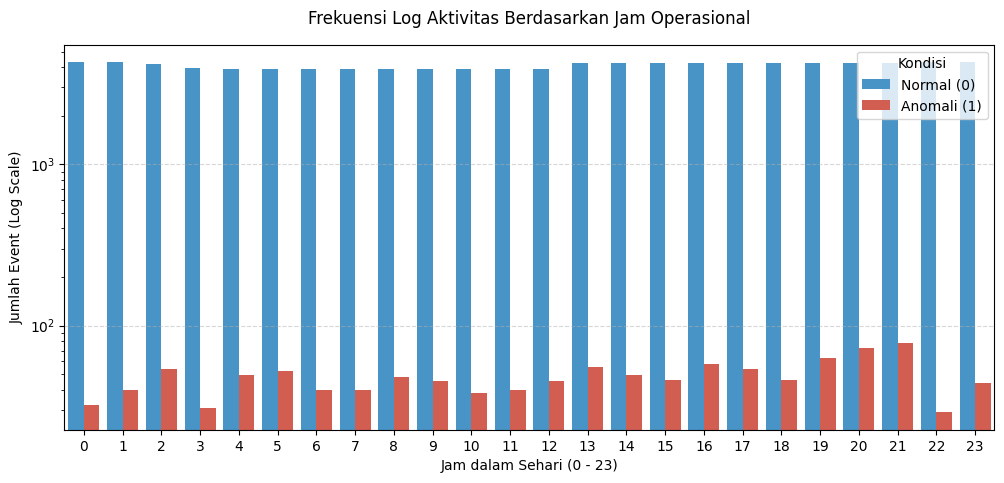

In [73]:
# Buat kolom 'hour' sementara hanya untuk visualisasi
df_events['hour_of_day'] = df_events['event_time'].dt.hour

plt.figure(figsize=(12, 5))
# Gunakan countplot untuk menghitung frekuensi event per jam
ax = sns.countplot(
    data=df_events, 
    x='hour_of_day', 
    hue='target', 
    palette=['#3498db', '#e74c3c']
)

plt.title('Frekuensi Log Aktivitas Berdasarkan Jam Operasional', pad=15)
plt.xlabel('Jam dalam Sehari (0 - 23)')
plt.ylabel('Jumlah Event (Log Scale)')
# Kita wajib gunakan skala log pada sumbu Y karena jumlah anomali sangat kecil (imbalanced data)
plt.yscale('log') 

plt.legend(title='Kondisi', labels=['Normal (0)', 'Anomali (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Hapus kolom sementara agar tidak mengotori dataframe untuk modeling nanti
df_events.drop(columns=['hour_of_day'], inplace=True)

Baik log normal maupun anomali tersebar secara merata di sepanjang 24 jam (0 - 23). Tidak ada jam tertentu yang menunjukkan lonjakan signifikan untuk anomali, yang mengindikasikan bahwa aktivitas mencurigakan dapat terjadi kapan saja sepanjang hari. 

Secara realitas bisnis, aktivitas log normal seharusnya memuncak pada jam kerja (08:00 - 17:00) dan menurun drastis di malam hari. Penyebaran yang sangat rata ini merupakan artefak dari fungsi looping waktu linier pada skrip generator yang berjalan konstan tanpa memedulikan siklus ritme sirkadian (siang-malam) pengguna.

Modeling

In [74]:
df_events['target'].value_counts(normalize=True)

target
0    0.98851
1    0.01149
Name: proportion, dtype: float64

In [75]:
features = [
    'is_clearance_violation', 'is_terminated_access', 'is_high_risk_action',
    'is_outside_working_hours', 'is_weekend', 'rolling_bytes_1h',
    'rolling_failed_logins_1h', 'event_count_1h'
]

In [76]:
X = df_events[features]
y = df_events['target']

In [77]:
# Parameter 'stratify=y' wajib digunakan agar proporsi kelas anomali yang sangat kecil (1.15%) 
# tetap terbagi secara adil antara data latih dan data uji.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [80]:
print(f"Dimensi Data Training : {X_train.shape[0]} events (Anomali: {y_train.sum()})")
print(f"Dimensi Data Testing  : {X_test.shape[0]} events (Anomali: {y_test.sum()})")

Dimensi Data Training : 80000 events (Anomali: 919)
Dimensi Data Testing  : 20000 events (Anomali: 230)


In [81]:
# class_weight='balanced' digunakan untuk memberi "hukuman" lebih berat kepada model jika salah menebak kelas minoritas (Anomali)
rf_model = RandomForestClassifier(
    n_estimators=100,        # Menggunakan 100 pohon keputusan
    max_depth=10,            # Membatasi kedalaman pohon agar tidak overfitting ke data buatan
    class_weight='balanced', # Solusi teknis untuk imbalanced dataset
    random_state=42, 
    n_jobs=-1                # Menggunakan seluruh core CPU agar training instan
)

In [82]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [83]:
y_pred = rf_model.predict(X_test)

In [84]:
class_report_str = classification_report(y_test, y_pred, target_names=['Normal (0)', 'Anomali (1)'])
print("Classification Report:\n", class_report_str)

Classification Report:
               precision    recall  f1-score   support

  Normal (0)       0.99      0.96      0.98     19770
 Anomali (1)       0.11      0.40      0.17       230

    accuracy                           0.96     20000
   macro avg       0.55      0.68      0.58     20000
weighted avg       0.98      0.96      0.97     20000

